<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Exercise 6 — Output Analysis (Single Model)

Summer Semester 26

Prof. Dr. Gunther Gust <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

In [1]:
# Imports — run once
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# D3 colour palette
D3_BLUE   = '#1f77b4'
D3_ORANGE = '#ff7f0e'
D3_GREEN  = '#2ca02c'
D3_RED    = '#d62728'
D3_GRAY   = '#7f7f7f'

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[D3_BLUE, D3_ORANGE, D3_GREEN, D3_RED, D3_GRAY])

# Overview — five parts

| Part | Topic | Context |
|---|---|---|
| **A** | Replication-method CI for the mean | Terminating: 4-hour rush hour, $R$ runs |
| **B** | Quantile CI (95th percentile) | Distribution-free CI via order statistics |
| **C** | Sample size for a target precision | Pilot → required $R$ for half-width $\le \varepsilon$ |
| **D** | Welch's method — find $T_0$ | Steady-state: ensemble + moving average |
| **E** | Batch means + Fishman iteration | Steady-state: single long run, $k$ batches, check $\rho_1$ |

The gas station model is **provided** — your job is to apply the output-analysis tools from the lecture.

## The model — provided

In [2]:
# Provided model — a 2-pump gas station (rho = 0.75)
# DO NOT modify this cell.

class EventLogger:
    """Records every simulation event as a DataFrame row."""
    def __init__(self, verbose=False):
        self.events = []
        self.verbose = verbose
    def log(self, **kwargs):
        if self.verbose:
            print('  '.join(f'{k}={v}' for k, v in kwargs.items()))
        self.events.append(kwargs)
    def get_df(self):
        return pd.DataFrame(self.events)


class GasStation:
    def __init__(self, env, num_pumps, mean_service):
        self.env = env
        self.pumps = simpy.Resource(env, capacity=num_pumps)
        self.mean_service = mean_service
    def serve(self):
        yield self.env.timeout(random.expovariate(1 / self.mean_service))


class Car:
    def __init__(self, env, name, station, logger):
        self.env, self.name, self.station, self.logger = env, name, station, logger
    def run(self):
        arrive = self.env.now
        self.logger.log(t=round(arrive, 2), name=self.name, event='arrives')
        with self.station.pumps.request() as req:
            yield req
            wait = self.env.now - arrive
            self.logger.log(t=round(self.env.now, 2), name=self.name,
                            event='starts service', wait=round(wait, 2))
            yield self.env.process(self.station.serve())
            self.logger.log(t=round(self.env.now, 2), name=self.name, event='leaves')


def car_generator(env, station, logger, mean_inter):
    i = 0
    while True:
        yield env.timeout(random.expovariate(1 / mean_inter))
        env.process(Car(env, f'C{i}', station, logger).run())
        i += 1


def run_gas_station(seed, num_pumps=2, mean_inter=4.0, mean_service=6.0,
                    sim_time=240, verbose=False):
    """One simulation run of the gas station. Returns the event log as a DataFrame."""
    random.seed(seed)
    env = simpy.Environment()
    station = GasStation(env, num_pumps=num_pumps, mean_service=mean_service)
    logger = EventLogger(verbose=verbose)
    env.process(car_generator(env, station, logger, mean_inter))
    env.run(until=sim_time)
    return logger.get_df()


# Helper: extract per-car waiting times from a run
def waits_of(df):
    return df.loc[df['event'] == 'starts service', 'wait'].reset_index(drop=True)


# Quick sanity test
df_test = run_gas_station(seed=1)
print(f'Run length: 240 min, customers served (sample): {len(waits_of(df_test))}')
print(f'Mean wait this run: {waits_of(df_test).mean():.2f} min')

Run length: 240 min, customers served (sample): 61
Mean wait this run: 2.12 min


# Part A — Replication-method CI

A 4-hour rush hour at the gas station is a **terminating** simulation: the rush starts at a defined time, ends at a defined time, and the question is about *that shift*.

## Task A.1 — Run R = 10 independent replications

Run the provided model 10 times (seeds 1..10), each for `sim_time = 240` minutes. For each replication, compute the mean wait per car. Collect these 10 per-replication means.

Then compute the **95% confidence interval for the long-run mean wait during a 4-hour rush hour** using the replication-method formula.

Report: grand mean, sample SD across replications, $t$-critical value, half-width, and the CI.

In [3]:
# SOLUTION — Task A.1
R = 10
rep_means = np.array([waits_of(run_gas_station(seed=s)).mean() for s in range(1, R+1)])

grand_mean = rep_means.mean()
S = rep_means.std(ddof=1)
t_crit = stats.t.ppf(0.975, df=R-1)
H = t_crit * S / np.sqrt(R)

print(f'Per-replication means: {np.round(rep_means, 2)}')
print(f'Grand mean:    {grand_mean:.2f} min')
print(f'Sample SD:     {S:.3f} min')
print(f't_{{0.025, {R-1}}} = {t_crit:.3f}')
print(f'Half-width H:  {H:.3f} min')
print(f'95% CI:        [{grand_mean - H:.2f}, {grand_mean + H:.2f}] min')

Per-replication means: [ 2.12 18.56  8.1   3.75  1.32  4.7   9.77  9.99 10.72  8.15]
Grand mean:    7.72 min
Sample SD:     5.093 min
t_{0.025, 9} = 2.262
Half-width H:  3.644 min
95% CI:        [4.08, 11.36] min


## Task A.2 — Plot 20 replications against the CI band

Now run **20 independent replications** (seeds 1..20). Recompute the CI from these 20 replications, then fill in the plot skeleton below.

Then answer this conceptual question in a markdown cell:

> *Your 95% CI is centred on the grand mean. Naively, students often expect about $5\% \times 20 = 1$ of the per-replication dots to fall outside the band. In reality you probably see many more (or many fewer) outside. **Why?***

Per-replication means outside the 95% CI band: 13 of 20


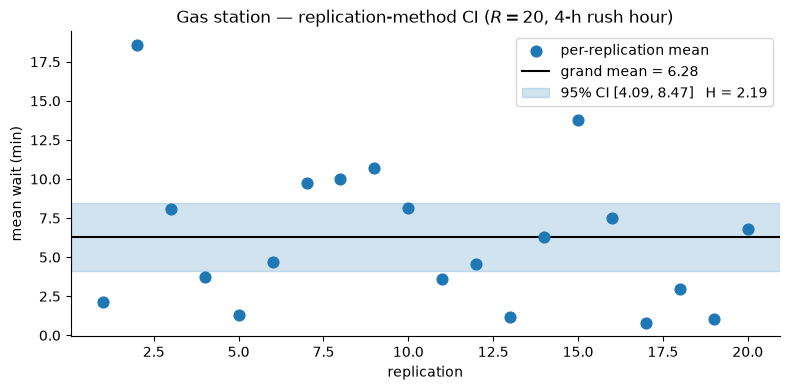

In [4]:
# SOLUTION — Task A.2
R2 = 20
rep_means_20 = np.array([waits_of(run_gas_station(seed=s)).mean() for s in range(1, R2 + 1)])

grand_mean_20 = rep_means_20.mean()
S_20 = rep_means_20.std(ddof=1)
t_crit_20 = stats.t.ppf(0.975, df=R2 - 1)
H_20 = t_crit_20 * S_20 / np.sqrt(R2)

n_outside = np.sum((rep_means_20 < grand_mean_20 - H_20) |
                   (rep_means_20 > grand_mean_20 + H_20))
print(f'Per-replication means outside the 95% CI band: {n_outside} of {R2}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(1, R2 + 1), rep_means_20, s=60, color=D3_BLUE, zorder=3,
           label='per-replication mean')
ax.axhline(grand_mean_20, color='black', lw=1.5, label=f'grand mean = {grand_mean_20:.2f}')
ax.axhspan(grand_mean_20 - H_20, grand_mean_20 + H_20, alpha=0.2, color=D3_BLUE,
           label=f'95% CI [{grand_mean_20 - H_20:.2f}, {grand_mean_20 + H_20:.2f}]   '
                 f'H = {H_20:.2f}')
ax.set_xlabel('replication')
ax.set_ylabel('mean wait (min)')
ax.set_title('Gas station — replication-method CI ($R = 20$, 4-h rush hour)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

**Answer — why isn't it ~1 of 20 outside?**

The 95% CI band is a **confidence interval for the true mean $\mu$**, not a *prediction interval* for individual replication means. Its half-width is $t \cdot S/\sqrt R$ — it shrinks with $\sqrt R$.

A prediction interval for an individual $\bar Y_r$ would have half-width $\approx t \cdot S$ (no $\sqrt R$ in the denominator) — that interval would contain ~95% of the dots.

So the band you plot is **$\sqrt R$ times narrower** than the band that would contain 95% of the dots. With $R = 20$, the band is about $\sqrt{20} \approx 4.5$ times narrower than the "95%-of-dots" band, which is why many dots fall outside.

**Bottom line:** the coverage statement "$\sim$ 95% contain the true $\mu$" is about *the bands constructed in many parallel experiments*, not about individual dots inside the present band.

# Part B — Quantile CI

Management cares about the *worst-served customers*: they want the **95th percentile** of waiting time to be inside a service-level target.

## Task B.1 — Estimate the 95th percentile of waiting time

Pool all per-car waiting times from your $R = 10$ replications into one big sorted array. Compute the **point estimate** of the 95th percentile.

Then construct a 95% confidence interval for the true 95th percentile using the order-statistic formula (normal approximation) from the lecture. Print:
- the total number of pooled waits $N$,
- the point estimate (which order statistic is it?),
- the two order statistic indices $l$ and $u$,
- the CI bounds.

In [5]:
# SOLUTION — Task B.1
all_waits = np.sort(np.concatenate([
    waits_of(run_gas_station(seed=s)).values for s in range(1, R+1)
]))
N = len(all_waits)
p = 0.95
alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

q_idx = int(np.ceil(N * p))               # 1-indexed
q_hat = all_waits[q_idx - 1]

l = int(np.floor(N*p - z*np.sqrt(N*p*(1-p)))) - 1   # 0-indexed array position
u = int(np.ceil( N*p + z*np.sqrt(N*p*(1-p)))) - 1

print(f'N = {N} pooled waits')
print(f'95th-percentile point estimate: {q_hat:.2f} min   (order stat {q_idx})')
print(f'CI bounds (order-stat indices): l = {l+1}, u = {u+1}   (1-indexed)')
print(f'95% CI for the 95th percentile: [Y_({l+1}), Y_({u+1})] = '
      f'[{all_waits[l]:.2f}, {all_waits[u]:.2f}] min')

N = 596 pooled waits
95th-percentile point estimate: 25.26 min   (order stat 567)
CI bounds (order-stat indices): l = 555, u = 577   (1-indexed)
95% CI for the 95th percentile: [Y_(555), Y_(577)] = [22.10, 34.51] min


## Task B.2 — Why is the CI not symmetric?

Compare the gap from the point estimate $\hat q_{0.95}$ to the **lower** CI bound with the gap to the **upper** CI bound. They are *not* equal.

In a markdown cell, answer:

> **Why is the order-statistic CI asymmetric around the point estimate, even though the index formula $l, u = Np \pm z\sqrt{Np(1-p)}$ places $l$ and $u$ **symmetrically** around the central position $Np$?**

**Answer.**

The index formula *is* symmetric: $l$ and $u$ sit equally many order-statistic positions away from $Np$. But the *values* $Y_{(l)}$ and $Y_{(u)}$ are not equally spaced — they depend on **how the data are distributed near the 95th percentile**.

Wait times in a heavily-loaded queue are strongly **right-skewed**: most cars wait short, a few wait very long. In the right tail (above the 95th percentile) observations are **sparse** — successive order statistics are far apart in value. Below the 95th percentile they are **dense** — successive order statistics are close together.

So a fixed step of "+10 positions" in the upper tail buys you a much larger jump in minutes than a step of "−10 positions" just below — and the CI is asymmetric upward.

This is one of the **strengths** of the order-statistic CI: it *automatically respects* the shape of the underlying distribution, without us having to model it. A symmetric CI of the form $\hat q \pm c$ would be wrong here.

# Part C — Sample size for a target precision

You want to report the mean wait with a precision of **± 0.5 min** at 95% confidence. Your $R = 10$ pilot replications from Part A give you a sample SD estimate.

## Task C.1 — Compute the required number of replications

Using the formula from the lecture and the $z$ approximation for the $t$-quantile, determine the smallest $R$ that achieves half-width $\le \varepsilon = 0.5$ min.

Print: pilot SD, target $\varepsilon$, $z$-critical, required $R$, and how many *additional* replications you'd need to collect.

In [6]:
# SOLUTION — Task C.1
R0 = R                          # pilot uses the R from Part A
s0 = S                          # pilot SD computed in Part A
eps = 0.5
alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

R_required = int(np.ceil((z * s0 / eps)**2))

print(f'Pilot:             R_0 = {R0}, pilot SD s_0 = {s0:.3f} min')
print(f'Target:            half-width <= {eps} min at {int((1-alpha)*100)}% confidence')
print(f'z_{{alpha/2}}     = {z:.3f}')
print(f'Required:          R >= {R_required} replications')
print(f'Additional needed: {max(0, R_required - R0)} replications')

Pilot:             R_0 = 10, pilot SD s_0 = 5.093 min
Target:            half-width <= 0.5 min at 95% confidence
z_{alpha/2}     = 1.960
Required:          R >= 399 replications
Additional needed: 389 replications


# Part D — Welch's method for warmup detection

Now suppose the gas station is open 24/7 and we want the **long-run** mean wait — not the 4h-rush-hour mean. This is a **steady-state** problem. The first cars after opening face an empty queue and bias the mean.

## Task D.1 — Apply Welch's method

Run $R = 30$ replications, each long enough to collect at least 400 cars per replication (use `sim_time = 2000`). Build the ensemble average over the first 400 customer indices. Then apply a moving average with window $w = 15$ (so the smoothed line averages over 31 values).

Plot:
- one raw replication (lightly), as background
- the ensemble mean ($R = 30$)
- the moving-average-smoothed ensemble mean
- a vertical dashed line at your visually chosen $T_0$.

Comment in a markdown cell which $T_0$ you pick and why.

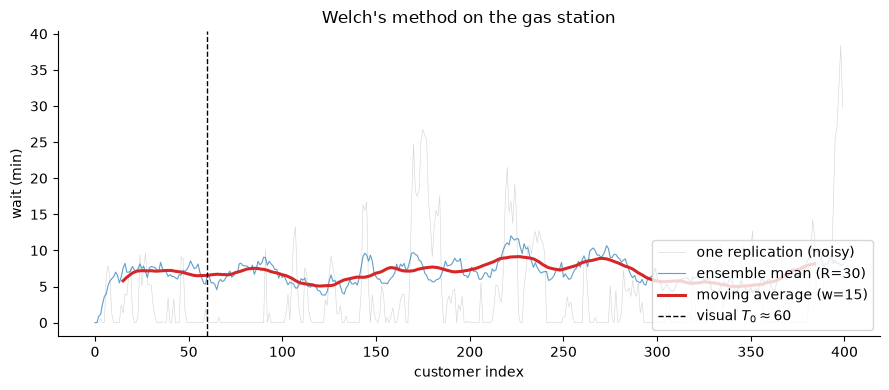

In [7]:
# SOLUTION — Task D.1
R_welch = 30
n_obs = 400

ensemble = []
for s in range(1, R_welch + 1):
    df = run_gas_station(seed=s, sim_time=2000)
    w = waits_of(df).values
    if len(w) >= n_obs:
        ensemble.append(w[:n_obs])
ensemble = np.array(ensemble)
ens_mean = ensemble.mean(axis=0)

def moving_average(x, w):
    out = np.full_like(x, np.nan, dtype=float)
    for i in range(w, len(x) - w):
        out[i] = x[i-w:i+w+1].mean()
    return out

w_ma = 15
smoothed = moving_average(ens_mean, w_ma)
T0_visual = 60   # visually chosen plateau start (adjust if your plot suggests otherwise)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ensemble[0], lw=0.4, color='lightgray', label='one replication (noisy)')
ax.plot(ens_mean, lw=0.8, color=D3_BLUE, alpha=0.7, label=f'ensemble mean (R={R_welch})')
ax.plot(smoothed, lw=2.2, color=D3_RED, label=f'moving average (w={w_ma})')
ax.axvline(T0_visual, color='black', ls='--', lw=1,
           label=f'visual $T_0 \\approx {T0_visual}$')
ax.set_xlabel('customer index')
ax.set_ylabel('wait (min)')
ax.set_title("Welch's method on the gas station")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Your $T_0$ choice and reasoning:**
The smoothed (red) curve rises steeply for the first ~30–50 customers, then flattens
into a near-constant plateau. I pick $T_0 \approx 60$ to be safely past the warmup
trend; rule of thumb: when in doubt, choose $T_0$ too large rather than too small.

# Part E — Batch means + Fishman iteration

Now we use a **single long run** (`sim_time = 80000`) and form batch means. We need to choose the batch size $m$ such that consecutive batch means are approximately uncorrelated.

## Task E.1 — Implement Fishman's iterative procedure

Write code that:
1. Takes the post-warmup data array (delete the first $T_0$ customers from Task D, say $d = 60$).
2. Starts with $k = 1000$ batches (small batches → likely correlated, the iteration has to actually do something).
3. Computes the lag-1 autocorrelation $\rho_1$ of the batch means.
4. If $|\rho_1| > 0.2$ **and** $k \ge 20$: halve $k$ (double $m$) and repeat.
5. Stops when $|\rho_1| \le 0.2$ (or $k$ would fall below 10).

Print, for **each** iteration, the current $(k, m, \rho_1)$. Highlight the final choice.

In [8]:
# SOLUTION — Task E.1
df_long = run_gas_station(seed=99, sim_time=80000)
waits_long = waits_of(df_long).iloc[60:].values   # delete first 60 (warmup from Part D)

print(f'Post-warmup observations N = {len(waits_long)}')

k = 1000
target = 0.2
while True:
    m = len(waits_long) // k
    batches = waits_long[:k*m].reshape(k, m)
    batch_means = batches.mean(axis=1)
    rho1 = pd.Series(batch_means).autocorr(lag=1)
    print(f'  k = {k:4d}, m = {m:6d}, rho_1 = {rho1:+.3f}')
    if abs(rho1) <= target or k <= 20:
        break
    k //= 2

print(f'\n→ Final choice: k = {k}, m = {m}, rho_1 = {rho1:+.3f}')

Post-warmup observations N = 19972
  k = 1000, m =     19, rho_1 = +0.540
  k =  500, m =     39, rho_1 = +0.294
  k =  250, m =     79, rho_1 = +0.102

→ Final choice: k = 250, m = 79, rho_1 = +0.102


## Task E.2 — Build the batch-means CI and explain the difference to Part A

Using the $(k, m)$ from Task E.1, compute:
- the batch means,
- the grand mean,
- the variance estimator of the grand mean,
- the 95% CI.

Print your batch-means CI **next to** the replication-method CI from Part A. They will *not* match. In a markdown cell answer:

> **Why do the two CIs estimate (slightly) different quantities, even though they use the same gas-station model with the same utilisation $\rho = 0.75$?**

In [9]:
# SOLUTION — Task E.2
truncated = waits_long[:k*m]
batches = truncated.reshape(k, m)
batch_means = batches.mean(axis=1)

grand = batch_means.mean()
var_hat = batch_means.var(ddof=1) / k
t_crit_bm = stats.t.ppf(0.975, k - 1)
H_bm = t_crit_bm * np.sqrt(var_hat)

print(f'Batch-means CI ({k} batches of size {m}):')
print(f'   grand mean      = {grand:.2f} min')
print(f'   95% CI          = [{grand - H_bm:.2f}, {grand + H_bm:.2f}]   half-width {H_bm:.3f}')
print()
print(f'Replication CI from Part A (R=10, terminating 4h rush hour):')
print(f'   grand mean      = {grand_mean:.2f} min')
print(f'   95% CI          = [{grand_mean - H:.2f}, {grand_mean + H:.2f}]   half-width {H:.3f}')

Batch-means CI (250 batches of size 79):
   grand mean      = 7.39 min
   95% CI          = [6.59, 8.20]   half-width 0.802

Replication CI from Part A (R=10, terminating 4h rush hour):
   grand mean      = 7.72 min
   95% CI          = [4.08, 11.36]   half-width 3.644


**Why are the two CIs different?**

The two CIs target **two genuinely different population quantities** — there is no a priori reason their values should agree or even overlap:

- **Part A — terminating CI** estimates the *mean wait during a 4-hour rush hour starting from an empty station*. The first cars arrive into an empty queue → their waits are 0 → in expectation this pulls the rush-hour mean *below* the steady-state mean.
- **Part E — batch-means CI** estimates the *long-run steady-state mean*, with the empty-start bias deleted via warmup.

Each CI is correct *for its own target* — they answer different questions and are not directly comparable.

A secondary observation: Part A's CI is much wider (~3.6 min half-width from $R = 10$ short runs) than Part E's (~0.8 min from 250 nearly-independent batches in one long run). The wide Part-A CI means its point estimate is very noisy — so even though theory says the rush-hour mean should sit *below* the steady-state mean, a single experiment with $R = 10$ can easily produce a higher point estimate (as happens here). To actually *compare* the two quantities reliably, you would need to run Part A with many more replications until its CI is narrow enough to resolve the warmup-bias effect.

# Short questions

*Format and length are comparable to the exam. Use them to self-test your understanding.*

## Q1 — Time average from a step function  *(4 pts)*

A single counter's queue length over a 10-minute window is recorded as the following step function:

| Interval | Length | $Y(t)$ |
|---|---|---|
| [0, 3) | 3 min | 0 |
| [3, 5) | 2 min | 1 |
| [5, 6) | 1 min | 3 |
| [6, 10) | 4 min | 2 |

(a) Compute the time-average queue length $\bar Y$ over $[0, 10]$.
(b) Write the general formula relating $\int_0^{T_E} Y(t)\,dt$ to the step-function values.

**Solution.**
(a) $\bar Y = (0\cdot 3 + 1\cdot 2 + 3\cdot 1 + 2\cdot 4)/10 = (0+2+3+8)/10 = 1.3$ customers.
(b) $\int_0^{T_E} Y(t)\,dt = \sum_k Y_k \Delta t_k$ where $Y_k$ is the value during segment $k$ and $\Delta t_k$ its length. Hence $\bar Y = \tfrac{1}{T_E}\sum_k Y_k \Delta t_k$.

## Q2 — Construct a CI from raw numbers  *(4 pts)*

You have $n = 5$ iid observations with $\bar Y = 10$ and $S = 3$. Construct a 95% confidence interval for $\mu$. Use $t_{0.025, 4} \approx 2.776$.

**Solution.** Half-width $H = t_{0.025, 4}\cdot S/\sqrt n = 2.776 \cdot 3/\sqrt 5 \approx 2.776 \cdot 1.342 \approx 3.724$. CI = $[10 - 3.72,\ 10 + 3.72] = [6.28,\ 13.72]$.

## Q3 — Variance of $\bar Y$ from first principles  *(6 pts)*

For iid $Y_1, \ldots, Y_n$ with $E[Y_i] = \mu$ and $\mathrm{Var}(Y_i) = \sigma^2$:

(a) State the two basic rules for the expectation and variance of a linear combination of random variables. For the variance rule, name the required assumption.
(b) Using these rules, derive $E[\bar Y]$ and $\mathrm{Var}(\bar Y)$ for $\bar Y = \tfrac{1}{n}\sum Y_i$.
(c) Interpret the role of $\sqrt n$ in the resulting standard deviation.

**Solution.**
(a) Linearity of expectation: $E[\sum a_i X_i] = \sum a_i E[X_i]$ (always). Variance of a linear combination: $\mathrm{Var}(\sum a_i X_i) = \sum a_i^2 \mathrm{Var}(X_i)$, assuming the $X_i$ are independent (or at least uncorrelated).
(b) With $a_i = 1/n$:
   $E[\bar Y] = \tfrac{1}{n}\sum E[Y_i] = \tfrac{1}{n}\cdot n\mu = \mu$.
   $\mathrm{Var}(\bar Y) = \sum \tfrac{1}{n^2}\mathrm{Var}(Y_i) = \tfrac{n\sigma^2}{n^2} = \sigma^2/n$.
(c) Standard deviation $\sigma/\sqrt n$ shrinks with $\sqrt n$ — quadrupling $n$ halves the SE. This is the foundation of *more data = more precision*.

## Q4 — Sample-size formula's blind spot  *(5 pts)*

The standard sample-size formula $R \ge (z_{\alpha/2}\cdot s_0/\varepsilon)^2$ uses the $z$ approximation, not the actual $t_{\alpha/2, R-1}$ which would depend on the unknown $R$.

(a) In which regime (small or large $R$) is this approximation **worst**?
(b) In that regime, does the formula tend to *underestimate* or *overestimate* the truly required $R$?
(c) What is a simple iterative fix?

**Solution.**
(a) Worst for *small* $R$ (small degrees of freedom), where $t_{\alpha/2, R-1}$ is noticeably larger than $z_{\alpha/2}$.
(b) Since $t > z$, the true required $R$ is *larger* than what the $z$-approximation suggests — the formula **underestimates** $R$.
(c) Plug the formula's $R$ back to look up $t_{\alpha/2, R-1}$, recompute $R$ with $t$ in place of $z$, repeat until convergence (usually one or two iterations).

# 🧠 Mentimeter — your turn (4 questions)

➡️ Open the Mentimeter and answer the four questions on screen.